# 02 · H2 — 통제가능 vs 구조적 기여 분해 (지도학습)

**가설:** 전환은 셀러가 *바꿀 수 있는* 표현(사진·설명·상대가격)보다 *못 바꾸는*
구조(브랜드수요·가격대·카테고리)에 더 좌우된다 → 일반 가이드가 "노력→판매"를
과대포장한다. 또한 통제가능 레버의 효과는 세그먼트별로 이질적이다.

**방법:** (1) 통제가능-only vs 전체 피처 AUC 비교(셀러 통제력의 상한),
(2) permutation importance 그룹 기여 분해, (3) 가격대별 이질성.
view_count/like_count는 누수 → 제외.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
matplotlib.rcParams["font.family"] = "AppleGothic"
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
FIG = ROOT / "results" / "figures"

lst = pd.read_parquet(ROOT / "data" / "cache" / "features_listing.parquet")
lst["rel_price_missing"] = lst["relative_price_z"].isna().astype(int)
lst["relative_price_z"] = lst["relative_price_z"].fillna(0.0)
lst["condition"] = lst["condition"].fillna("UNK")
lst["category_l1"] = lst["category_l1"].fillna("UNK")
lst["category_l2"] = lst["category_l2"].fillna("UNK")
y = lst["is_sold"].astype(int).values
print("N =", len(lst), "| sold rate =", f"{y.mean():.3f}")

N = 284654 | sold rate = 0.215


## 1. 피처 그룹 정의 (통제가능 vs 구조)

누수 가드: view_count/like_count는 데이터에 없음(피처 테이블에서 이미 제외).

In [2]:
CONTROLLABLE = ["n_photos", "desc_len", "n_lines", "n_hashtag", "n_emoji",
                "kw_measure", "kw_flaw", "kw_material", "kw_purchase", "kw_usage", "kw_wash",
                "discount_pct", "has_discount", "relative_price_z", "rel_price_missing"]
STRUCT_NUM = ["log_price", "age_days"]
STRUCT_CAT = ["brand_top", "category_l1", "category_l2", "condition"]

assert not ({"view_count", "like_count", "likes"} & set(lst.columns)), "누수 컬럼 존재!"

# category_l2 고카디널리티 → top20 + OTHER
top_l2 = lst["category_l2"].value_counts().head(20).index
lst["category_l2"] = lst["category_l2"].where(lst["category_l2"].isin(top_l2), "OTHER")

def make_X(which):
    parts = []
    if which in ("controllable", "full"):
        parts.append(lst[CONTROLLABLE].astype(float))
    if which in ("structural", "full"):
        parts.append(lst[STRUCT_NUM].astype(float))
        for c in STRUCT_CAT:
            parts.append(pd.get_dummies(lst[c], prefix=c, drop_first=True).astype(float))
    return pd.concat(parts, axis=1)

X_ctrl, X_struct, X_full = make_X("controllable"), make_X("structural"), make_X("full")
print("dims:", X_ctrl.shape[1], X_struct.shape[1], X_full.shape[1])

dims: 15 54 69


## 2. AUC 비교 — 셀러 통제력의 상한

통제가능-only AUC가 0.5에 가까우면 셀러가 움직일 수 있는 레버의 예측력이 약하다는 뜻.

In [3]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)
def xgb():
    return XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                         subsample=0.8, colsample_bytree=0.8, tree_method="hist",
                         eval_metric="logloss", n_jobs=-1, random_state=42)

auc = {}
for name, X in [("controllable", X_ctrl), ("structural", X_struct), ("full", X_full)]:
    s = cross_val_score(xgb(), X, y, cv=cv, scoring="roc_auc", n_jobs=1)
    auc[name] = {"auc_mean": round(s.mean(), 4), "auc_std": round(s.std(), 4)}
    print(f"  {name:12s} AUC = {s.mean():.4f} ± {s.std():.4f}")

# 로지스틱 baseline (통제가능-only)
log_auc = cross_val_score(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=500)),
    X_ctrl, y, cv=cv, scoring="roc_auc").mean()
print(f"  (logistic controllable-only AUC = {log_auc:.4f})")

  controllable AUC = 0.6246 ± 0.0029


  structural   AUC = 0.7675 ± 0.0019


  full         AUC = 0.7876 ± 0.0017


  (logistic controllable-only AUC = 0.6116)


## 3. 기여 분해 — permutation importance (그룹 합산)

전체 모델에서 피처를 셔플했을 때 AUC 하락폭. 통제가능 vs 구조 그룹별 합산.

holdout AUC: 0.7861



그룹별 기여 합 (permutation, AUC 하락):
구조(아이템)     0.2718
통제가능(표현)    0.0403
dtype: float64
비율: {'구조(아이템)': 0.871, '통제가능(표현)': 0.129}

Top 12 피처:
brand_top_OTHER           0.1213
category_l2_상의            0.0203
log_price                 0.0160
rel_price_missing         0.0127
category_l2_주얼리           0.0117
category_l2_액세서리          0.0093
brand_top_Stone Island    0.0088
relative_price_z          0.0083
category_l2_라이프           0.0071
brand_top_Vintage         0.0056
desc_len                  0.0053
brand_top_Levi's          0.0051
dtype: float64


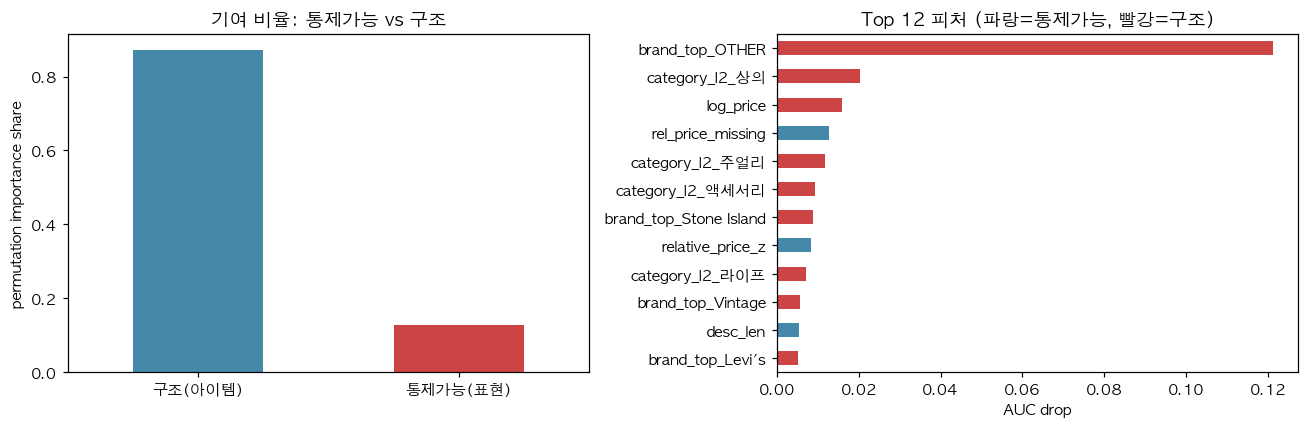

In [4]:
Xtr, Xte, ytr, yte = train_test_split(X_full, y, test_size=0.15, stratify=y, random_state=42)
clf = xgb().fit(Xtr, ytr)
print("holdout AUC:", round(roc_auc_score(yte, clf.predict_proba(Xte)[:, 1]), 4))

# 속도 위해 holdout 일부로 permutation
idx = np.random.RandomState(0).choice(len(Xte), size=min(30000, len(Xte)), replace=False)
perm = permutation_importance(clf, Xte.iloc[idx], yte[idx], scoring="roc_auc",
                              n_repeats=5, random_state=0, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_full.columns).sort_values(ascending=False)

def group_of(col):
    if col in CONTROLLABLE:
        return "통제가능(표현)"
    return "구조(아이템)"

grp = imp.groupby(imp.index.map(group_of)).sum()
grp_share = (grp / grp.sum()).round(3)
print("\n그룹별 기여 합 (permutation, AUC 하락):")
print(grp.round(4))
print("비율:", grp_share.to_dict())
print("\nTop 12 피처:")
print(imp.head(12).round(4))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(grp_share).plot(kind="bar", ax=ax[0], rot=0, color=["#48a", "#c44"])
ax[0].set(title="기여 비율: 통제가능 vs 구조", ylabel="permutation importance share")
imp.head(12)[::-1].plot(kind="barh", ax=ax[1],
                        color=[("#48a" if group_of(c)=="통제가능(표현)" else "#c44") for c in imp.head(12).index[::-1]])
ax[1].set(title="Top 12 피처 (파랑=통제가능, 빨강=구조)", xlabel="AUC drop")
fig.tight_layout(); fig.savefig(FIG / "h2_contribution.png", bbox_inches="tight"); plt.show()

## 4. 이질성 — 가격대별 통제가능 레버의 예측력

In [5]:
het = {}
for tier, sub in lst.groupby("price_tier", observed=True):
    if len(sub) < 2000:
        continue
    Xc = sub[CONTROLLABLE].astype(float)
    ys = sub["is_sold"].astype(int).values
    if ys.mean() in (0, 1):
        continue
    a = cross_val_score(xgb(), Xc, ys, cv=3, scoring="roc_auc", n_jobs=1).mean()
    het[str(tier)] = round(a, 4)
    print(f"  {tier}: controllable-only AUC = {a:.4f}  (n={len(sub):,}, sold={ys.mean():.2f})")

  1_low<3만: controllable-only AUC = 0.6393  (n=21,943, sold=0.20)


  2_mid<8만: controllable-only AUC = 0.6508  (n=78,230, sold=0.21)


  3_high<20만: controllable-only AUC = 0.6015  (n=94,820, sold=0.23)


  4_top20만+: controllable-only AUC = 0.5724  (n=89,661, sold=0.21)


## 5. 결과 저장

In [6]:
h2 = {
    "n": int(len(lst)),
    "auc": auc,
    "logistic_controllable_auc": round(float(log_auc), 4),
    "auc_gap_full_minus_controllable": round(auc["full"]["auc_mean"] - auc["controllable"]["auc_mean"], 4),
    "contribution_share": {k: float(v) for k, v in grp_share.items()},
    "top_features": {k: round(float(v), 4) for k, v in imp.head(12).items()},
    "controllable_auc_by_price_tier": het,
}
(ROOT / "results" / "h2.json").write_text(
    json.dumps(h2, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(h2, ensure_ascii=False, indent=2))

{
  "n": 284654,
  "auc": {
    "controllable": {
      "auc_mean": 0.6246,
      "auc_std": 0.0029
    },
    "structural": {
      "auc_mean": 0.7675,
      "auc_std": 0.0019
    },
    "full": {
      "auc_mean": 0.7876,
      "auc_std": 0.0017
    }
  },
  "logistic_controllable_auc": 0.6116,
  "auc_gap_full_minus_controllable": 0.163,
  "contribution_share": {
    "구조(아이템)": 0.871,
    "통제가능(표현)": 0.129
  },
  "top_features": {
    "brand_top_OTHER": 0.1213,
    "category_l2_상의": 0.0203,
    "log_price": 0.016,
    "rel_price_missing": 0.0127,
    "category_l2_주얼리": 0.0117,
    "category_l2_액세서리": 0.0093,
    "brand_top_Stone Island": 0.0088,
    "relative_price_z": 0.0083,
    "category_l2_라이프": 0.0071,
    "brand_top_Vintage": 0.0056,
    "desc_len": 0.0053,
    "brand_top_Levi's": 0.0051
  },
  "controllable_auc_by_price_tier": {
    "1_low<3만": 0.6393,
    "2_mid<8만": 0.6508,
    "3_high<20만": 0.6015,
    "4_top20만+": 0.5724
  }
}
